Alexander Jon Solis & Sean Maverick Virata
Global Supply Chain Resillience Architect dataset

Imports pandas

In [231]:
import pandas as pd
import os
import matplotlib.pyplot as plt 
import numpy as np

Imports the GPR dataset

In [232]:
current_dir = os.getcwd()
data_gpr_export = pd.read_csv(f'{current_dir}\\data_gpr_export_og.csv')
data_gpr_export['Year'] = pd.to_datetime(data_gpr_export['month'])
data_gpr_export['Year'] = data_gpr_export['Year'].dt.year

List of country columns

In [233]:
countries = [
    "Argentina", "Australia", "Belgium", "Brazil", "Canada", "Chile", "China", "Hong_Kong", "Taiwan",
    "Colombia", "Denmark", "Egypt", "Finland", "France", "Germany", "Hungary", "India", "Indonesia",
    "Israel", "Italy", "Japan", "Malaysia", "Mexico", "Netherlands", "Norway", "Peru", "Philippines",
    "Poland", "Portugal", "South_Korea", "Russia", "Saudi_Arabia", "South_Africa", "Spain", "Sweden",
    "Switzerland", "Thailand", "Tunisia", "Turkiye", "Ukraine", "United_Kingdom", "United_States",
    "Venezuela", "Viet_Nam"
]

Group by year and calculate mean for each country, then round to 2 decimals

In [234]:
data_gpr_annual = data_gpr_export.groupby('Year')[countries].mean().round(2).reset_index()

View data_gpr_annual

In [235]:
print(data_gpr_annual)

     Year  Argentina  Australia  Belgium  Brazil  Canada  Chile  China  \
0    1900       0.02       0.08     0.08    0.02    0.10   0.02   0.81   
1    1901       0.04       0.03     0.04    0.03    0.08   0.04   0.25   
2    1902       0.01       0.03     0.05    0.02    0.06   0.01   0.12   
3    1903       0.02       0.02     0.04    0.03    0.05   0.02   0.17   
4    1904       0.05       0.03     0.02    0.02    0.06   0.02   0.64   
..    ...        ...        ...      ...     ...     ...    ...    ...   
122  2022       0.04       0.24     0.41    0.11    0.30   0.02   1.12   
123  2023       0.03       0.17     0.19    0.11    0.22   0.02   0.99   
124  2024       0.03       0.13     0.15    0.09    0.12   0.02   0.71   
125  2025       0.02       0.12     0.15    0.08    0.22   0.01   0.64   
126  2026       0.10       0.16     0.18    0.13    0.29   0.04   1.04   

     Hong_Kong  Taiwan  ...  Sweden  Switzerland  Thailand  Tunisia  Turkiye  \
0         0.00    0.01  ...    

Imports the Trade merch total dataset

In [236]:
trademerch_gpr = pd.read_csv(f'{current_dir}\\TradeMerchTotal_og.csv')
trademerch_gpr['Year'] = pd.to_datetime(trademerch_gpr['Year']).dt.year
trademerch_gpr = trademerch_gpr.rename(columns={
    'Economy_Label': 'Country',
    'Flow_Label': 'Trade_Flow',
    'US_at_current_prices_in_millions_Value': 'Trade_Value'
})
trademerch_gpr = trademerch_gpr[['Year', 'Country', 'Trade_Flow', 'Trade_Value']]

Add ID column as auto-increment primary key and add GPRHI column initialized with None

In [237]:
trademerch_gpr.insert(0, 'ID', range(1, len(trademerch_gpr) + 1))
trademerch_gpr['GPRHI'] = None

Create a dictionary for mapping country names to column names in data_gpr_annual

In [238]:
country_to_col = {
    'Argentina': 'Argentina',
    'Australia': 'Australia',
    'Belgium': 'Belgium',
    'Brazil': 'Brazil',
    'Canada': 'Canada',
    'Chile': 'Chile',
    'China': 'China',
    'Colombia': 'Colombia',
    'Denmark': 'Denmark',
    'Egypt': 'Egypt',
    'Finland': 'Finland',
    'France': 'France',
    'Germany': 'Germany',
    'Hong_Kong': 'Hong_Kong',
    'Hungary': 'Hungary',
    'India': 'India',
    'Indonesia': 'Indonesia',
    'Israel': 'Israel',
    'Italy': 'Italy',
    'Japan': 'Japan',
    'Malaysia': 'Malaysia',
    'Mexico': 'Mexico',
    'Netherlands': 'Netherlands',
    'Norway': 'Norway',
    'Peru': 'Peru',
    'Philippines': 'Philippines',
    'Poland': 'Poland',
    'Portugal': 'Portugal',
    'Russia': 'Russia',
    'Saudi_Arabia': 'Saudi_Arabia',
    'South_Africa': 'South_Africa',
    'South_Korea': 'South_Korea',
    'Spain': 'Spain',
    'Sweden': 'Sweden',
    'Switzerland': 'Switzerland',
    'Taiwan': 'Taiwan',
    'Thailand': 'Thailand',
    'Tunisia': 'Tunisia',
    'Turkiye': 'Turkiye',
    'Ukraine': 'Ukraine',
    'United_Kingdom': 'United_Kingdom',
    'United_States': 'United_States',
    'Venezuela': 'Venezuela',
    'Viet_Nam': 'Viet_Nam'
}


Merge trademerch_gpr with data_gpr_annual on Year

In [239]:
merged = pd.merge(trademerch_gpr, data_gpr_annual, on='Year', how='left', suffixes=('', '_gpr'))

Function to get GPRHI value based on Country

In [240]:
def get_gprhi(row):
    col = country_to_col.get(row['Country'])
    if col and col in merged.columns:
        return row[col]
    return None

Apply function to assign GPRHI and drop the ID column

In [241]:
merged['GPRHI'] = merged.apply(get_gprhi, axis=1)
trademerch_gpr = merged[['ID', 'Year', 'Country', 'Trade_Flow', 'Trade_Value', 'GPRHI']]
trademerch_gpr = trademerch_gpr.drop(columns=['ID'])
trademerch_gpr = trademerch_gpr[(trademerch_gpr['Year'] >= 2021) & (trademerch_gpr['Year'] <= 2025)]

Display and export the trademerch_gpr 

In [242]:
trademerch_gpr
trademerch_gpr.to_csv('trademerch_gpr.csv')

In [243]:
print(trademerch_gpr.info())

<class 'pandas.core.frame.DataFrame'>
Index: 440 entries, 6422 to 6861
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         440 non-null    int32  
 1   Country      440 non-null    object 
 2   Trade_Flow   440 non-null    object 
 3   Trade_Value  440 non-null    float64
 4   GPRHI        440 non-null    float64
dtypes: float64(2), int32(1), object(2)
memory usage: 18.9+ KB
None


In [244]:
print(trademerch_gpr.describe())

              Year   Trade_Value       GPRHI
count   440.000000  4.400000e+02  440.000000
mean   2023.000000  4.699649e+05    0.332409
std       1.415823  6.170983e+05    0.619069
min    2021.000000  3.535000e+03    0.010000
25%    2022.000000  1.007275e+05    0.050000
50%    2023.000000  3.073560e+05    0.120000
75%    2024.000000  5.801415e+05    0.300000
max    2025.000000  3.771842e+06    4.040000


# 10 Exploratory Data Visualizations for Trade Merchandise GPR Dataset

## 1. Trade Value by Year - Line Plot (exports vs imports)

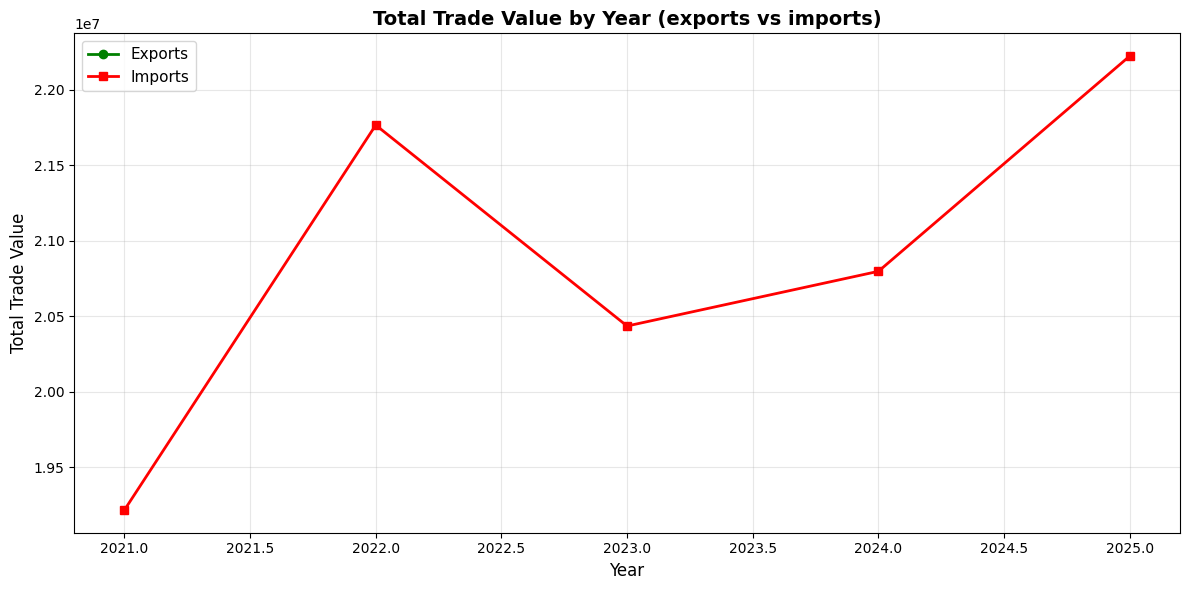

In [245]:
group_by_year = trademerch_gpr.groupby(['Year', 'Trade_Flow'])['Trade_Value'].sum().reset_index()
exports_yearly = group_by_year[group_by_year['Trade_Flow'] == 'export']
imports_yearly = group_by_year[group_by_year['Trade_Flow'] == 'Imports']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(exports_yearly['Year'], exports_yearly['Trade_Value'], marker='o', linewidth=2, label='Exports', color='green')
ax.plot(imports_yearly['Year'], imports_yearly['Trade_Value'], marker='s', linewidth=2, label='Imports', color='red')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Trade Value', fontsize=12)
ax.set_title('Total Trade Value by Year (exports vs imports)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Top 15 Countries by Average Trade Value

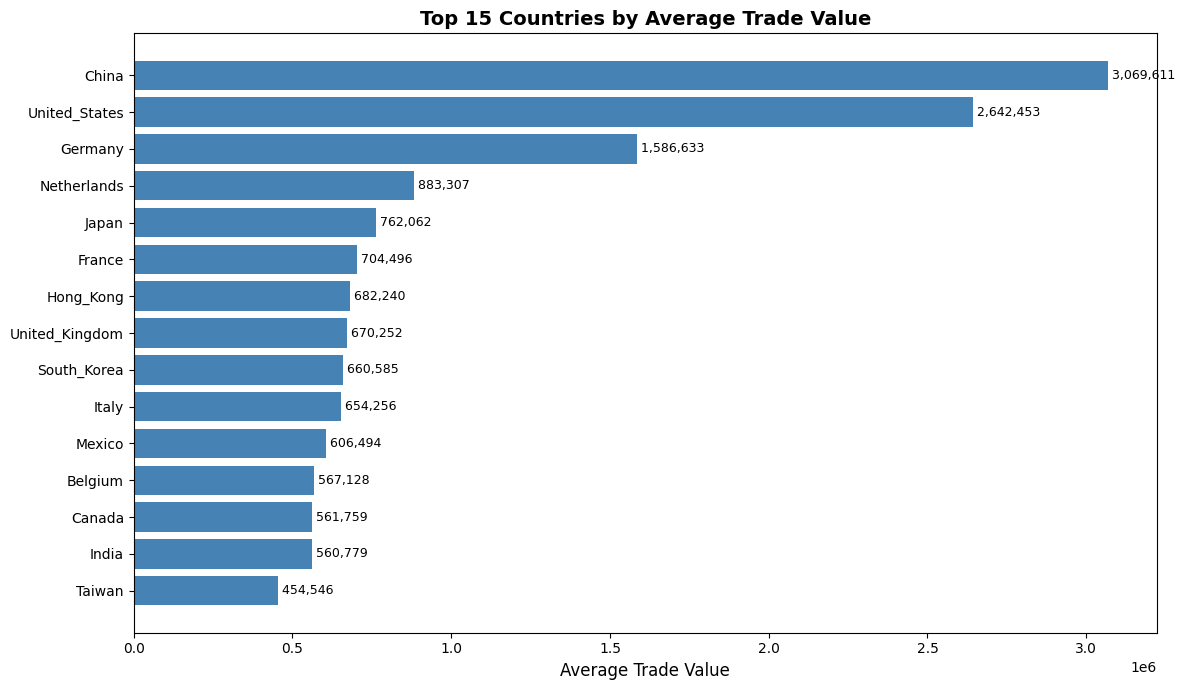

In [246]:
top_countries = trademerch_gpr.groupby('Country')['Trade_Value'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top_countries)), top_countries.values, color='steelblue')
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index)
ax.set_xlabel('Average Trade Value', fontsize=12)
ax.set_title('Top 15 Countries by Average Trade Value', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (bar, value) in enumerate(zip(bars, top_countries.values)):
    ax.text(value, i, f' {value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Distribution of Trade Values - Histogram

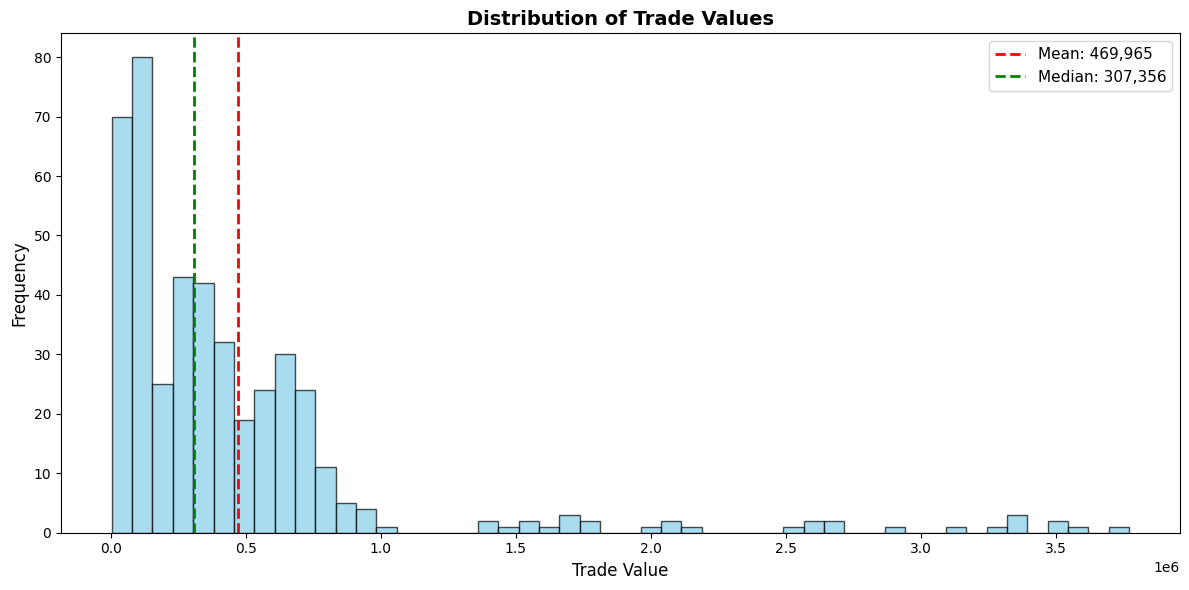

In [247]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(trademerch_gpr['Trade_Value'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Trade Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Trade Values', fontsize=14, fontweight='bold')
ax.axvline(trademerch_gpr['Trade_Value'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {trademerch_gpr["Trade_Value"].mean():,.0f}')
ax.axvline(trademerch_gpr['Trade_Value'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {trademerch_gpr["Trade_Value"].median():,.0f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 4. GPRHI Distribution by Trade Flow - Box Plot

C:\Users\Admin\AppData\Local\Temp\ipykernel_9700\3052490475.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([export_gprhi, Imports_gprhi], labels=['exports', 'imports'], patch_artist=True)


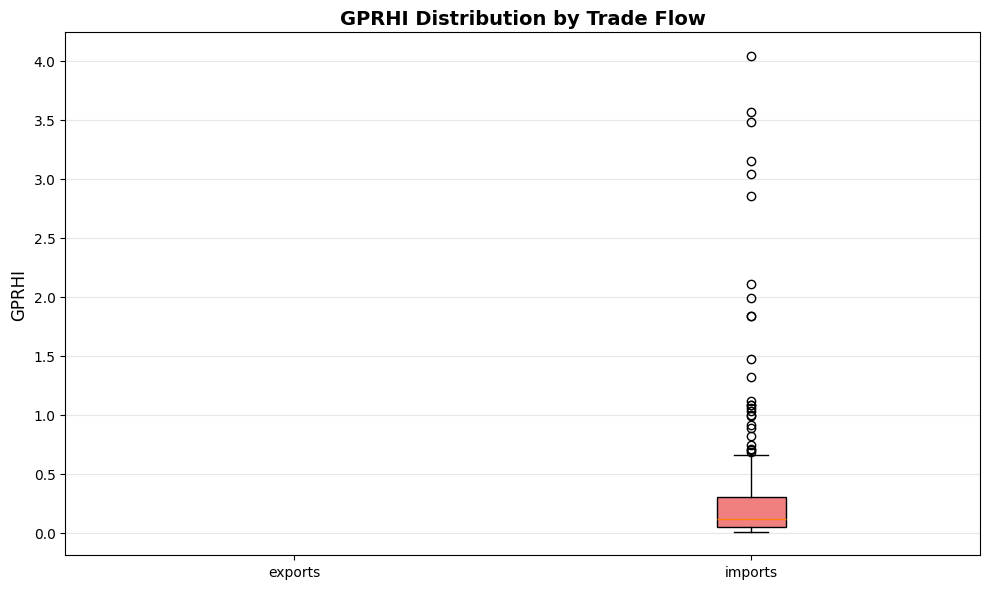

In [248]:
fig, ax = plt.subplots(figsize=(10, 6))
export_gprhi = trademerch_gpr[trademerch_gpr['Trade_Flow'] == 'export']['GPRHI']
Imports_gprhi = trademerch_gpr[trademerch_gpr['Trade_Flow'] == 'Imports']['GPRHI']

bp = ax.boxplot([export_gprhi, Imports_gprhi], labels=['exports', 'imports'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightgreen', 'lightcoral']):
    patch.set_facecolor(color)

ax.set_ylabel('GPRHI', fontsize=12)
ax.set_title('GPRHI Distribution by Trade Flow', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 5. Scatter Plot: Trade Value vs GPRHI

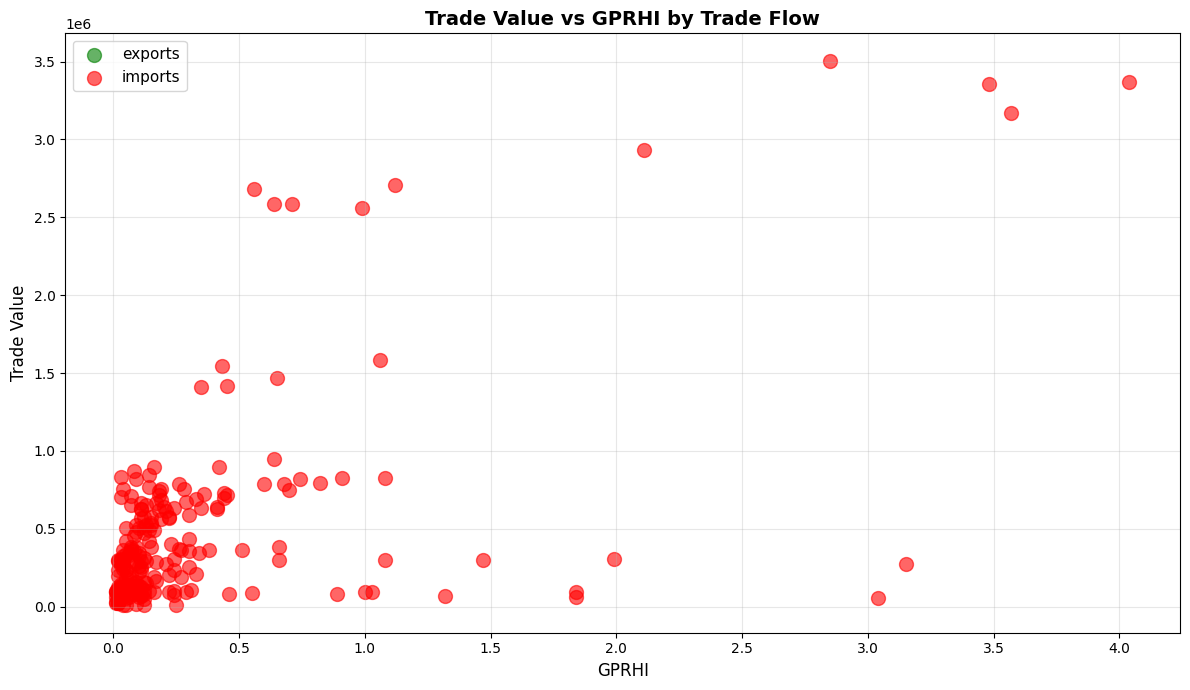

In [249]:
fig, ax = plt.subplots(figsize=(12, 7))

export_data = trademerch_gpr[trademerch_gpr['Trade_Flow'] == 'export']
Imports_data = trademerch_gpr[trademerch_gpr['Trade_Flow'] == 'Imports']

ax.scatter(export_data['GPRHI'], export_data['Trade_Value'], alpha=0.6, s=100, label='exports', color='green')
ax.scatter(Imports_data['GPRHI'], Imports_data['Trade_Value'], alpha=0.6, s=100, label='imports', color='red')

ax.set_xlabel('GPRHI', fontsize=12)
ax.set_ylabel('Trade Value', fontsize=12)
ax.set_title('Trade Value vs GPRHI by Trade Flow', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Heatmap: Average Trade Value by Year and Top 10 Countries

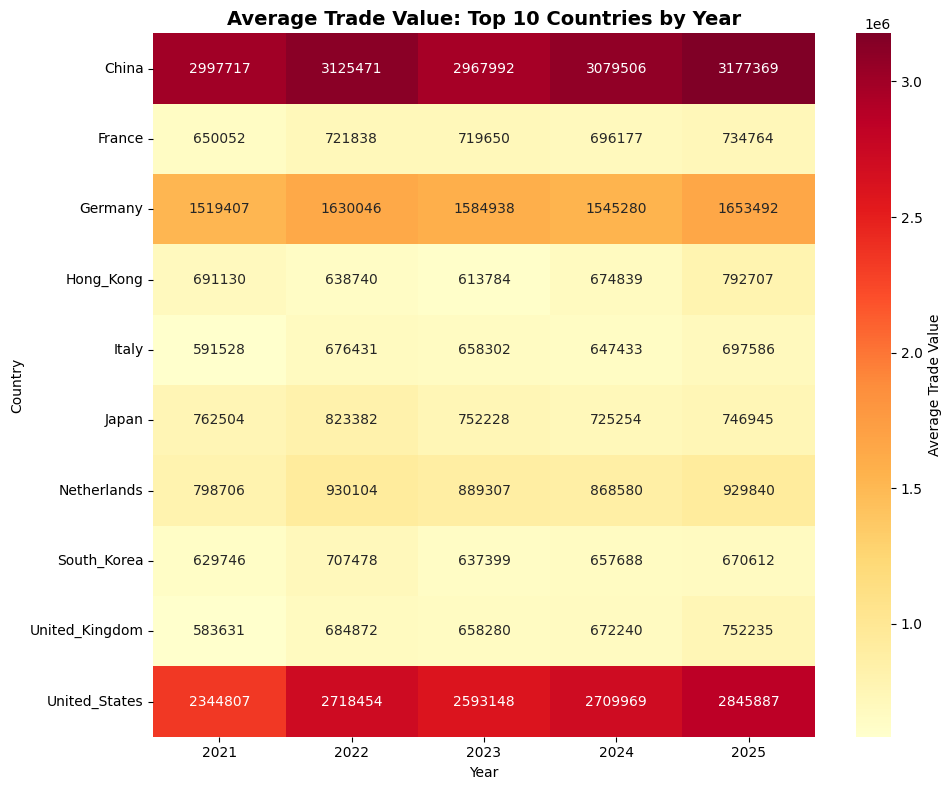

In [250]:
import seaborn as sns

top_10_countries = trademerch_gpr.groupby('Country')['Trade_Value'].mean().nlargest(10).index
pivot_data = trademerch_gpr[trademerch_gpr['Country'].isin(top_10_countries)].pivot_table(
    values='Trade_Value', index='Country', columns='Year', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Average Trade Value'}, ax=ax)
ax.set_title('Average Trade Value: Top 10 Countries by Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. exports vs imports Ratio by Top Countries

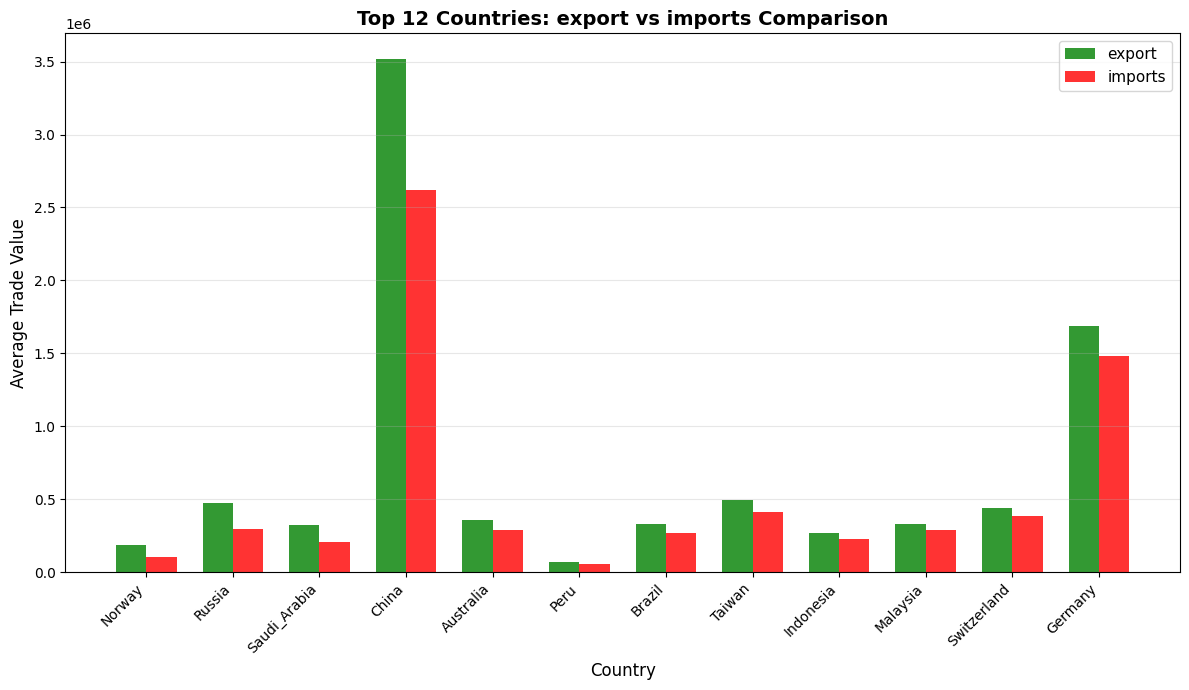

In [251]:
exports_imports_by_country = trademerch_gpr.pivot_table(
    values='Trade_Value', index='Country', columns='Trade_Flow', aggfunc='mean'
)
exports_imports_by_country['Ratio'] = exports_imports_by_country['Exports'] / exports_imports_by_country['Imports']
top_ratio = exports_imports_by_country.nlargest(12, 'Ratio')

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top_ratio))
width = 0.35

bars1 = ax.bar(x - width/2, top_ratio['Exports'], width, label='export', color='green', alpha=0.8)
bars2 = ax.bar(x + width/2, top_ratio['Imports'], width, label='imports', color='red', alpha=0.8)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Average Trade Value', fontsize=12)
ax.set_title('Top 12 Countries: export vs imports Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_ratio.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 8. GPRHI Distribution by Top 10 Countries - Violin Plot

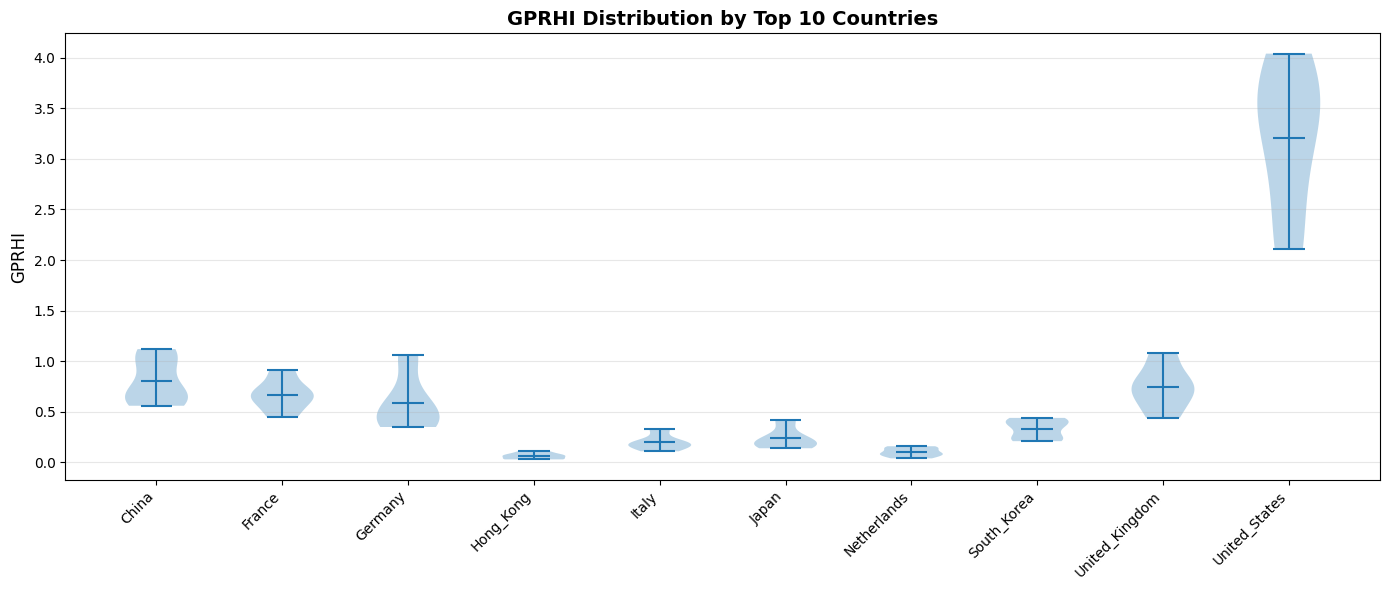

In [252]:
top_10_countries_by_trade = trademerch_gpr.groupby('Country')['Trade_Value'].mean().nlargest(10).index
top_10_data = trademerch_gpr[trademerch_gpr['Country'].isin(top_10_countries_by_trade)]

fig, ax = plt.subplots(figsize=(14, 6))
countries_list = sorted(top_10_data['Country'].unique())
data_by_country = [top_10_data[top_10_data['Country'] == country]['GPRHI'].values for country in countries_list]

parts = ax.violinplot(data_by_country, positions=range(len(countries_list)), showmeans=True)
ax.set_xticks(range(len(countries_list)))
ax.set_xticklabels(countries_list, rotation=45, ha='right')
ax.set_ylabel('GPRHI', fontsize=12)
ax.set_title('GPRHI Distribution by Top 10 Countries', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 9. Trade Flow Distribution Pie Chart

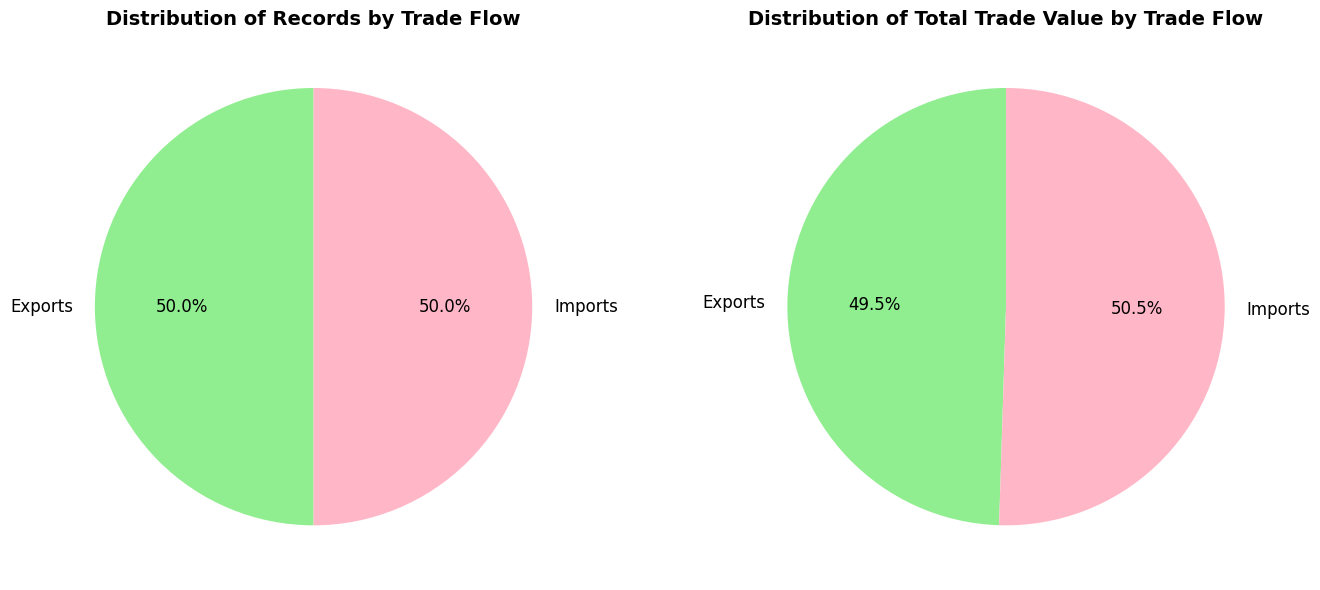

In [253]:
trade_flow_counts = trademerch_gpr['Trade_Flow'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#90EE90', '#FFB6C6']
ax1.pie(trade_flow_counts.values, labels=trade_flow_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 12})
ax1.set_title('Distribution of Records by Trade Flow', fontsize=14, fontweight='bold')

trade_flow_values = trademerch_gpr.groupby('Trade_Flow')['Trade_Value'].sum()
ax2.pie(trade_flow_values.values, labels=trade_flow_values.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12})
ax2.set_title('Distribution of Total Trade Value by Trade Flow', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Multi-metric Summary: Year Trends

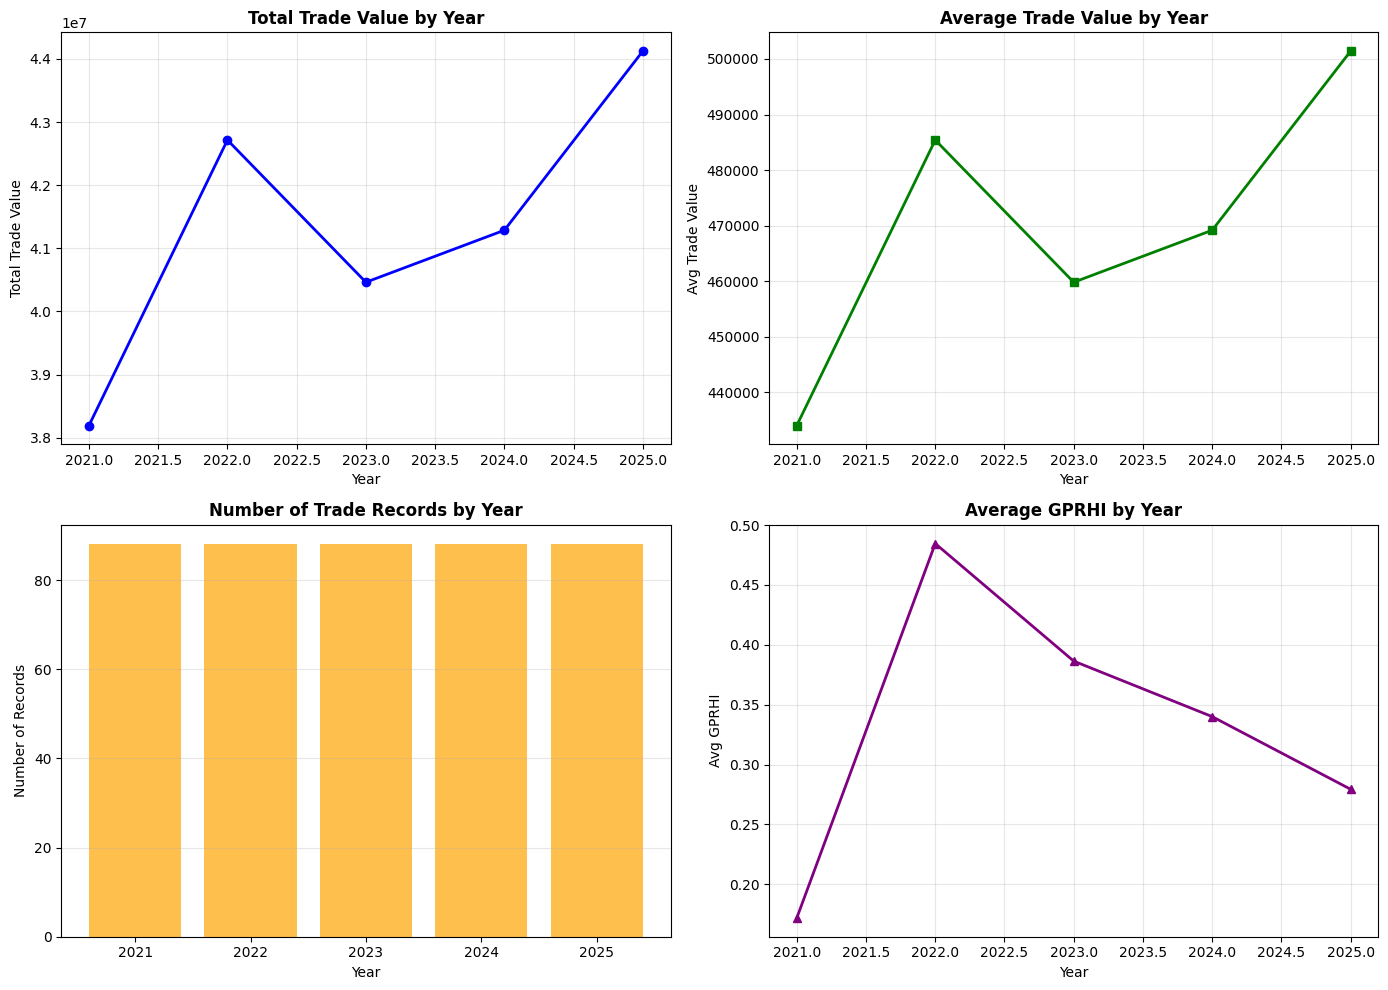

In [254]:
year_summary = trademerch_gpr.groupby('Year').agg({
    'Trade_Value': ['sum', 'mean', 'count'],
    'GPRHI': 'mean'
}).reset_index()

year_summary.columns = ['Year', 'Total_Trade_Value', 'Avg_Trade_Value', 'Num_Records', 'Avg_GPRHI']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(year_summary['Year'], year_summary['Total_Trade_Value'], marker='o', color='blue', linewidth=2)
axes[0, 0].set_title('Total Trade Value by Year', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Total Trade Value')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(year_summary['Year'], year_summary['Avg_Trade_Value'], marker='s', color='green', linewidth=2)
axes[0, 1].set_title('Average Trade Value by Year', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Avg Trade Value')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].bar(year_summary['Year'], year_summary['Num_Records'], color='orange', alpha=0.7)
axes[1, 0].set_title('Number of Trade Records by Year', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].plot(year_summary['Year'], year_summary['Avg_GPRHI'], marker='^', color='purple', linewidth=2)
axes[1, 1].set_title('Average GPRHI by Year', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Avg GPRHI')
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()
